In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M6 — สอนโมเดลจากภาพ "ปกติ" เพื่อจับความผิดปกติ (PatchCore)

**Day 3, 09:00–10:15 · Offline (CPU)**

โจทย์จริงของงานเมโทรโลยี/QC: ภาพ "ชำรุด" หายากและหน้าตาหลากหลายจนเก็บ label ไม่ไหว — แต่ภาพ "ปกติ" มีเพียบ โมดูลนี้จึงสอนโมเดลจาก**ภาพปกติราว 20 ใบเท่านั้น** แล้วให้มัน:

1. ให้ **คะแนน anomaly** กับภาพใหม่ว่า "แปลกจากของปกติแค่ไหน"
2. วาด **anomaly heatmap** ชี้ว่าความผิดปกติอยู่ตรงไหนของภาพ
3. เข้าใจหลักการของ **PatchCore** คร่าว ๆ ในโน้ตบุ๊กนี้ — เชิงลึกอยู่ใน `explanation.md`

เราใช้ **anomalib** (ไลบรารี anomaly detection ทางการของ Intel) บน CPU — ทั้งโมดูลรัน offline ได้ และในส่วน exercise ผู้เรียนจะถ่ายรูป**เครื่องมือ/ชิ้นงานของตัวเอง**มาใช้แทนชุดตัวอย่าง

## Dataset / โมเดลที่ใช้ (citation + license)

- **PatchCore** — Roth, K., Penate Sanchez, L., Meier, J., & Ommer, B. (2022). *Towards Total Recall in Industrial Anomaly Detection*. CVPR 2022 · arXiv:2106.08265 · ใช้ผ่าน anomalib <https://github.com/open-edge-platform/anomalib> · **License: Apache-2.0**
- **Backbone: WideResNet-50-2** — Zagoruyko & Komodakis (2016). *Wide Residual Networks*, arXiv:1605.07146 — weights จาก timm (`wide_resnet50_2.racm_in1k`, <https://huggingface.co/timm/wide_resnet50_2.racm_in1k>) **License: Apache-2.0** — ดาวน์โหลดครั้งแรก ~130 MB ลง cache ของ Hugging Face (`~/.cache/huggingface/`) บนเครื่อง offline ที่ pre-bundle แล้วจะโหลดจากดิสก์ทันที (ดูแผน pre-bundle ใน README)
- **หมายเหตุ license:** เรา**ไม่ใช้**ชุดข้อมูล MVTec AD ยอดนิยมของวงการนี้ เพราะเป็น **CC BY-NC-SA 4.0 (non-commercial)** — โมดูลนี้จึงใช้ภาพตัวอย่างสังเคราะห์ที่โน้ตบุ๊กสร้างเอง + รูปถ่ายของผู้เรียนแทน
- ไลบรารี: anomalib (Apache-2.0), PyTorch/torchvision (BSD-3-Clause), matplotlib (BSD), Pillow (MIT-CMU)

> **ขอบเขตการรัน:** เพื่อให้แล็บจบในไม่กี่นาทีบน CPU เราใช้ภาพ 256×256 จำนวน 20 ปกติ + 8 ชำรุด และ `num_neighbors=3` — PatchCore จริงในงานอุตสาหกรรมมักใช้ภาพหลักสิบถึงหลักร้อยและ `num_neighbors=9` (ดู `explanation.md`)

In [2]:
import logging  # noqa: E402
import warnings  # noqa: E402

warnings.filterwarnings("ignore")  # ตัด warning รบกวนจาก libs
logging.getLogger("lightning").setLevel(logging.ERROR)  # และ log ของ Lightning

from pathlib import Path  # noqa: E402


def repo_root() -> Path:
    'หา repo root โดยไล่ขึ้นจาก cwd.'
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise FileNotFoundError("ไม่เจอ repo root — เปิดโน้ตบุ๊กจากใน repo นี้")


ROOT = repo_root()

# backbone ของ anomalib (timm) — ใช้ datasets/models/hf ที่
# pre-bundle ไว้ถ้ามี; ถ้าไม่มี ใช้ default cache ตามเดิม
import os  # noqa: E402

_hf = ROOT / "datasets" / "models" / "hf"
if _hf.exists():
    os.environ["HF_HOME"] = str(_hf)
SAMPLE_DIR = ROOT / "data" / "m6_sample"   # ภาพตัวอย่าง (gitignored)
RUN_DIR = ROOT / "data" / "m6_results"     # ที่ anomalib เก็บ checkpoint
print(ROOT)

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31


## 1. โจทย์: มีแต่ตัวอย่าง "ปกติ" จะสร้างโมเดลได้ไหม?

ทุกโมดูลก่อนหน้า (M1) เราสอนโมเดลจำแนกด้วย**สองคลาส** — ปกติ + ชำรุด พร้อม label ครบ แต่ในงานจริง:

- **ภาพชำรุดหายากและหลากหลาย** — รอยขีดข่วน, รูสึก, คราบ, สนิม, แตก... เก็บตัวอย่างทุกแบบพร้อม label แพงมาก
- **ภาพปกติมีเยอะ** — ถ่ายชิ้นงานที่ผ่านการตรวจแล้วได้ทุกวัน

**ทางแก้: one-class anomaly detection** — สอนโมเดลจากภาพปกติ *เท่านั้น* ให้มันเรียนรู้ว่า "หน้าตาปกติ" เป็นอย่างไร แล้วตอนเจอภาพใหม่ ให้คะแนนว่า **"แปลกจากสิ่งที่เคยเห็นแค่ไหน"** — ไม่ต้องมี label ความชำรุดเลย ต่างจาก M1 ตรงที่:

| | M1 (classification) | M6 (anomaly detection) |
|---|---|---|
| ข้อมูลเทรน | 2 คลาส + label | คลาสเดียว (ปกติ) ไม่ต้องมี label |
| โมเดลเรียนรู้ | เส้นแบ่งระหว่างคลาส | "ขอบเขตความปกติ" |
| ตัวเลขที่ได้ | ความน่าจะเป็นต่อคลาส | คะแนน "ความแปลก" (ยิ่งสูงยิ่งน่าสงสัย) |
| เหมาะกับ | รู้ defect ชัดเจนล่วงหน้า | defect หลากหลาย/หายาก — โจทย์เมโทรโลยีทั่วไป |

## 2. ชุดภาพตัวอย่าง — สังเคราะห์ในโน้ตบุ๊ก

เพื่อให้รันได้ offline และ reproducible เราสร้างภาพตัวอย่างด้วย PIL: **แผ่นโลหะผิวขัด** 20 ใบ (ปกติ — ลายเส้นขนาน + grain + แสงตกต่างกันเล็กน้อยแบบของจริง) และ 8 ใบที่ชำรุด 4 แบบ (รอยขีดข่วน, รอยกัด, คราบไหม้, สนิม) ไฟล์จะถูกเขียนลง `data/m6_sample/` (โฟลเดอร์ `data/` ไม่ถูก commit)

> **ในแล็บจริง:** ให้แทนภาพชุดนี้ด้วย**รูปถ่ายของผู้เรียนเอง** — เครื่องมือ ชิ้นงาน หรือพื้นผิวอะไรก็ได้ที่ถ่ายซ้ำ ๆ ได้ วิธีถ่ายให้โมเดลใช้ได้จริงอยู่ใน `exercise.ipynb` ข้อ 1

In [3]:
import shutil  # noqa: E402

import numpy as np  # noqa: E402
from PIL import Image, ImageDraw  # noqa: E402

SEED = 42


def metal_plate(seed: int, w: int = 256, h: int = 256) -> Image.Image:
    'วาดแผ่นโลหะ "ปกติ": ลายเส้นผิวขัด + grain + แสงตกต่างกันเล็กน้อย.'
    r = np.random.default_rng(seed)
    gain = 1.0 + r.uniform(-0.06, 0.06)   # ความสว่างรวมต่างกันนิดหน่อย
    base = np.full((h, w, 3), 100.0)
    stripes = np.tile(np.arange(h), (w, 1)).T % 10 < 4
    base[stripes] -= 12                   # ลายเส้นผิวขัดแนวนอน
    noise = r.normal(0, 10, (h, w, 1))
    img = np.clip((base + noise) * gain, 0, 255).astype(np.uint8)
    for sl in (img[:8], img[-8:], img[:, :8], img[:, -8:]):
        sl[:] = np.clip(sl - 45, 0, 255)  # ขอบแผ่นโลหะเข้มกว่า
    return Image.fromarray(img)


def add_defect(img: Image.Image, kind: int, i: int) -> Image.Image:
    'วาดความชำรุด 4 แบบลงบนแผ่นโลหะ: ขีดข่วน/กัด/ไหม้/สนิม.'
    d = ImageDraw.Draw(img)
    if kind == 0:      # รอยขีดข่วนลึก
        x0 = 50 + (i * 9) % 110
        d.line([(x0, 45), (x0 + 18, 210)], fill=(10, 8, 6), width=9)
    elif kind == 1:    # รอยกัด/รูสึก
        cx, cy = 60 + (i * 11) % 100, 55 + (i * 13) % 100
        d.ellipse([cx, cy, cx + 26, cy + 26], fill=(240, 238, 232))
        d.ellipse([cx + 4, cy + 4, cx + 18, cy + 18], fill=(30, 25, 20))
    elif kind == 2:    # คราบไหม้
        cx, cy = 45 + (i * 17) % 110, 45 + (i * 19) % 100
        d.ellipse([cx, cy, cx + 52, cy + 44], fill=(28, 22, 16))
    else:              # สนิมกระจาย
        cx, cy = 55 + (i * 23) % 100, 50 + (i * 7) % 105
        d.ellipse([cx, cy, cx + 44, cy + 36], fill=(150, 70, 30))
        rr = np.random.default_rng(9000 + i)
        for _ in range(14):
            px = cx + int(rr.integers(2, 36))
            py = cy + int(rr.integers(2, 28))
            s = int(rr.integers(3, 7))
            d.ellipse([px, py, px + s, py + s], fill=(25, 15, 8))
    return img

In [4]:
N_GOOD, N_DEFECT = 20, 8
if SAMPLE_DIR.exists():
    shutil.rmtree(SAMPLE_DIR)
(SAMPLE_DIR / "good").mkdir(parents=True)
(SAMPLE_DIR / "defect").mkdir(parents=True)
for i in range(N_GOOD):
    metal_plate(1000 + i).save(SAMPLE_DIR / "good" / f"normal_{i:02d}.png")
for i in range(N_DEFECT):
    img = add_defect(metal_plate(3000 + i), kind=i % 4, i=i)
    img.save(SAMPLE_DIR / "defect" / f"defect_{i:02d}.png")
print("สร้างภาพแล้ว:", N_GOOD, "ปกติ +", N_DEFECT, "ชำรุด →", SAMPLE_DIR)

สร้างภาพแล้ว: 20 ปกติ + 8 ชำรุด → /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample


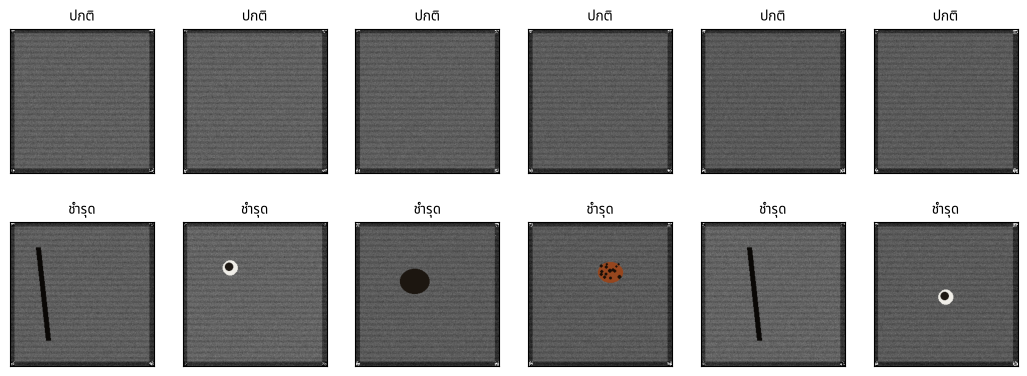

In [5]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Tahoma"]
good_paths = sorted((SAMPLE_DIR / "good").glob("*.png"))
defect_paths = sorted((SAMPLE_DIR / "defect").glob("*.png"))
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for j in range(6):
    axes[0, j].imshow(Image.open(good_paths[j]))
    axes[0, j].set_title("ปกติ", fontsize=10)
    axes[1, j].imshow(Image.open(defect_paths[j]))
    axes[1, j].set_title("ชำรุด", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

**อ่านภาพ:** แถวบนคือ "ปกติ" — หน้าตาคล้ายกันทั้งหมด (ต่างกันแค่ grain/แสงเล็กน้อย) แถวล่างคือ "ชำรุด" 4 แบบ โปรดสังเกตว่าเรา**ไม่ได้บอกโมเดลว่า defect หน้าตาอย่างไร** — โมเดลต้องค้นเองว่าจุดไหน "แปลก"

## 3. PatchCore ใน 1 นาที

PatchCore (Roth et al., CVPR 2022) เป็นวิธี anomaly detection ที่นิยมอันดับต้น ๆ ของงานตรวจ defect อุตสาหกรรม ไอเดียสั้น ๆ:

1. **สกัด feature ระดับ "patch"** — ผ่านภาพทุกใบเข้า CNN ที่เทรน ImageNet มาแล้ว (WideResNet-50-2) แต่**ไม่ได้ใช้ผลจำแนกท้ายเครือข่าย** — ใช้ feature กลาง ๆ (`layer2`, `layer3`) ซึ่งยังเก็บตำแหน่งในภาพไว้: ภาพ 256×256 → กริด patch feature หลายพันชิ้น
2. **สร้าง memory bank จากภาพปกติ** — เก็บ patch feature ของทุกภาพปกติไว้ แล้ว**ย่อ**ด้วย *coreset subsampling* (เลือก subset ที่ "คลุม" ทุก patch ได้ใกล้ที่สุด) ให้เล็กลงเหลือราว 1–10% โดยไม่เสียความครอบคลุม
3. **ให้คะแนนภาพใหม่** — patch แต่ละชิ้นของภาพใหม่ หา **ระยะไปเพื่อนบ้านสนิทใน memory bank** (kNN) — patch ที่หาเพื่อนไม่เจอ = น่าสงสัย → ประกอบเป็น **anomaly map** (heatmap) และใช้ค่า**สูงสุด**เป็นคะแนนของทั้งภาพ

ข้อดีใหญ่: **"การเทรน" ไม่มี gradient descent เลย** — แค่รัน backbone แล้วเก็บ/ย่อ feature จึงเร็วมาก ใช้ข้อมูลน้อย (หลักสิบภาพก็ทำงานได้) และตีความง่าย — เหมาะกับโจทย์เมโทรโลยีพอดี รายละเอียดเชิงลึก (ทำไม layer2/3, coreset greedy + Johnson–Lindenstrauss, smoothing, threshold) อยู่ใน `explanation.md`

In [6]:
import torch  # noqa: E402

torch.manual_seed(SEED)   # coreset selection ใช้ random — ล็อกให้ reproducible

## 4. เทรนด้วย anomalib — `Folder` + `Patchcore` + `Engine`

anomalib มี 3 ชิ้นหลัก:

- **`Folder`** (datamodule) — อ่านภาพจากโฟลเดอร์เรา: `normal_dir` = ภาพปกติ (ใช้เทรน), `abnormal_dir` = ภาพชำรุด (ใช้ทดสอบเท่านั้น — PatchCore ไม่แตะตอนเทรน)
- **`Patchcore`** (โมเดล)
- **`Engine`** — ตัวคุมการเทรน/ทำนาย (ครอบ PyTorch Lightning)

พารามิเตอร์ที่ตั้งต่างจากค่า default และเหตุผล:

| พารามิเตอร์ | ค่า | เพราะอะไร |
|---|---|---|
| `num_workers=0` | (datamodule) | จำเป็นบน macOS/Windows ที่รันใน notebook — worker แยก process แล้วล้ม; ข้อมูลเล็กก็ไม่จำเป็นต้องขนาน |
| `post_processor=False` | (โมเดล) | default ของ anomalib จะ normalize คะแนนเทียบ threshold อัตโนมัติจนเหลือแทบ 0/1 — เราอยากได้**คะแนนดิบ** (ระยะ kNN จริง) เพื่อเลือก threshold เองแบบนักเมโทรโลยี |
| `visualizer=False` | (โมเดล) | ไม่ให้ anomalib เขียนไฟล์ heatmap เอง — เราจะวาดเองด้วย matplotlib เพื่อเรียนรู้กลไก |
| `accelerator="cpu"` | (engine) | บังคับ CPU ให้ตรงสภาพแวดล้อม offline ของผู้เรียน |

In [7]:
from anomalib.data import Folder  # noqa: E402
from anomalib.engine import Engine  # noqa: E402
from anomalib.models import Patchcore  # noqa: E402

datamodule = Folder(
    name="m6_sample",
    root=str(SAMPLE_DIR),
    normal_dir="good",       # ภาพปกติ — ใช้เทรน
    abnormal_dir="defect",   # ภาพชำรุด — ใช้ทดสอบเท่านั้น
    val_split_mode="from_test",
    val_split_ratio=0.3,
    num_workers=0,
    seed=SEED,
)
model = Patchcore(
    layers=("layer2", "layer3"),   # feature "กลาง" ของ WideResNet-50
    num_neighbors=3,               # k ของ kNN ต่อ patch
    post_processor=False,
    visualizer=False,
)
engine = Engine(
    accelerator="cpu",
    max_epochs=1,                  # PatchCore ไม่ต้องเทรนหลาย epoch
    logger=False,
    default_root_dir=str(RUN_DIR),
    enable_progress_bar=False,
)

In [8]:
engine.fit(model=model, datamodule=datamodule)

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


20 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample/good. Please make sure this is intended.


8 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-31/data/m6_sample/defect. Please make sure this is intended.


...

Selecting Coreset Indices.:  80%|███████▉  | 1305/1637 [00:00<00:00, 1472.55it/s]

Selecting Coreset Indices.:  89%|████████▉ | 1454/1637 [00:01<00:00, 1476.84it/s]

Selecting Coreset Indices.:  98%|█████████▊| 1602/1637 [00:01<00:00, 1473.95it/s]

Selecting Coreset Indices.: 100%|██████████| 1637/1637 [00:01<00:00, 1450.04it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


**สังเกต:** จบในไม่กี่วินาทีบน CPU — สิ่งที่ `fit` ทำคือ (1) รัน backbone ผ่านภาพปกติ (2) เก็บ patch features เป็น memory bank (3) รัน *coreset selection* (แถบ "Selecting Coreset Indices") ย่อ memory bank — **ไม่มี gradient, ไม่มี loss, weight ของ backbone ไม่ถูกอัปเดตเลย** นี่คือเหตุผลที่ 1 epoch พอ และที่ไม่ต้องใช้ GPU (checkpoint ที่ anomalib บันทึกอยู่ใน `data/m6_results/` — gitignored)

## 5. ให้คะแนนภาพ — คะแนนดิบคือ "ระยะไป patch ปกติที่ใกล้สุด"

ฟังก์ชันช่วย `score_paths()` ทำ 3 ขั้นตรงกับทฤษฎี: โหลดภาพ → ผ่าน `pre_processor` ของโมเดล (resize 256×256 + normalize ด้วยค่าเฉลี่ย ImageNet) → ป้อนเข้า `model(batch)` ตรง ๆ (ไม่ผ่าน dataloader — เพื่อให้เห็นกลไกชัดและใช้กับ**รูปไหนก็ได้**)

In [9]:
from torchvision.transforms.v2.functional import to_dtype  # noqa: E402
from torchvision.transforms.v2.functional import to_image  # noqa: E402


def prep(path: str) -> torch.Tensor:
    'โหลดภาพ 1 ใบ → tensor ที่โมเดลคาดหวัง (256×256, normalized).'
    img = to_image(Image.open(path).convert("RGB"))
    return model.pre_processor(to_dtype(img, torch.float32, scale=True))


def score_paths(paths: list[str], batch_size: int = 8):
    'ให้คะแนนภาพหลายใบ → (scores, anomaly maps ขนาด 256×256 ต่อใบ).'
    scores, maps = [], []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(paths), batch_size):
            batch = torch.stack([prep(p) for p in paths[i:i + batch_size]])
            out = model(batch)          # InferenceBatch ของ anomalib
            scores.append(out.pred_score)
            maps.append(out.anomaly_map.squeeze(1))
    return torch.cat(scores).numpy(), torch.cat(maps).numpy()

In [10]:
s_good, _ = score_paths([str(p) for p in good_paths])
s_def, maps_def = score_paths([str(p) for p in defect_paths])
print("คะแนนภาพปกติ :", np.round(s_good, 0))
print("คะแนนภาพชำรุด:", np.round(s_def, 0))

คะแนนภาพปกติ : [182. 159. 187. 160. 161. 190. 198. 157. 155. 160. 159. 199. 152. 162.
 149. 171. 157. 152. 160. 175.]
คะแนนภาพชำรุด: [266. 245. 501. 233. 246. 216. 496. 216.]


AUC = 1.000   threshold (p95 ของภาพปกติ) = 198


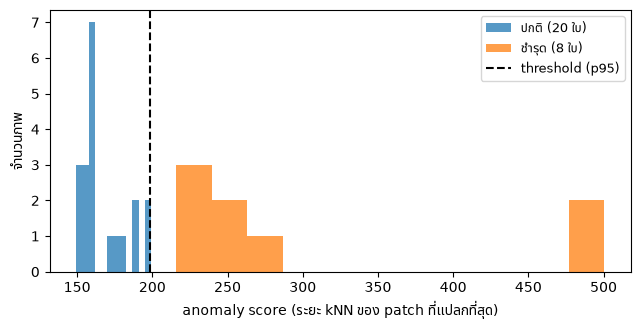

In [11]:
from sklearn.metrics import roc_auc_score  # noqa: E402

y_true = [0] * len(s_good) + [1] * len(s_def)
y_score = np.concatenate([s_good, s_def])
auc = roc_auc_score(y_true, y_score)

# threshold เทียบกับ "ภาพปกติ" — 95% ของปกติต้องต่ำกว่าเส้นนี้
THRESHOLD = float(np.percentile(s_good, 95))
print(f"AUC = {auc:.3f}   threshold (p95 ของภาพปกติ) = {THRESHOLD:.0f}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(s_good, bins=12, alpha=0.75, label="ปกติ (20 ใบ)")
ax.hist(s_def, bins=12, alpha=0.75, label="ชำรุด (8 ใบ)")
ax.axvline(THRESHOLD, color="k", ls="--", lw=1.5, label="threshold (p95)")
ax.set_xlabel("anomaly score (ระยะ kNN ของ patch ที่แปลกที่สุด)")
ax.set_ylabel("จำนวนภาพ")
ax.legend(fontsize=9)
plt.show()

**อ่านกราฟ:** คะแนนคือ "ระยะของ patch ที่แปลกที่สุด ไปหา patch ปกติที่ใกล้สุดใน memory bank" — ภาพปกติทุกใบมี patch ทุกชิ้นคล้ายของที่เคยเห็น จึงได้คะแนนต่ำ ภาพชำรุดมีอย่างน้อยหนึ่ง patch (จุด defect) ที่**หาเพื่อนไม่เจอ** จึงได้คะแนนสูง

**การเลือก threshold คือการตัดสินใจเชิงเมโทรโลยี ไม่ใช่คณิตศาสตร์:**

- **threshold ต่ำ** → จับ defect ได้ครบ (FN น้อย) แต่**ปลอมเตือนบ่อย** (FP สูง) — เสียเวลาตรวจซ้ำของที่จริงปกติ
- **threshold สูง** → เตือนน้อยลง แต่**ตรวจพลาด** (FN สูง) — ของชำรุดหลุดไปถึงลูกค้า

ในงานสอบเทียบ/ตรวจรับ ต้นทุนของ "ตรวจพลาด" มักสูงกว่า "ปลอมเตือน" มาก จึงนิยมตั้ง threshold ต่ำกว่าจุดสมดุล F1 ลงไปหน่อย (ที่นี่เราเลือก p95 ของภาพปกติ — FP ราว 5% ของภาพปกติโดยดีไซน์)

In [12]:
tp = int((s_def > THRESHOLD).sum())   # ชำรุดที่จับได้
fn = int(len(s_def) - tp)             # ชำรุดที่หลุด
fp = int((s_good > THRESHOLD).sum())  # ปกติที่ถูกเตือนมั่ว
tn = int(len(s_good) - fp)            # ปกติที่ผ่านถูกต้อง
print(f"threshold = {THRESHOLD:.0f}")
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}"
      f"  →  accuracy = {(tp + tn) / (len(s_def) + len(s_good)):.2f}")

threshold = 198
TP=8  FN=0  FP=1  TN=19  →  accuracy = 0.96


## 6. Anomaly heatmap — โมเดลชี้จุดชำรุดให้ดู

`anomaly_map` คือ **ระยะ kNN ของแต่ละ patch** — anomalib upsample จากกริด patch (หยาบ) กลับมาที่ขนาดภาพ 256×256 แล้ว smooth ด้วย Gaussian เล็กน้อย จุดสีสว่าง = จุดที่ patch "หาเพื่อนบ้านใน memory bank ไม่เจอ" = ตำแหน่งความชำรุดที่โมเดลเดา

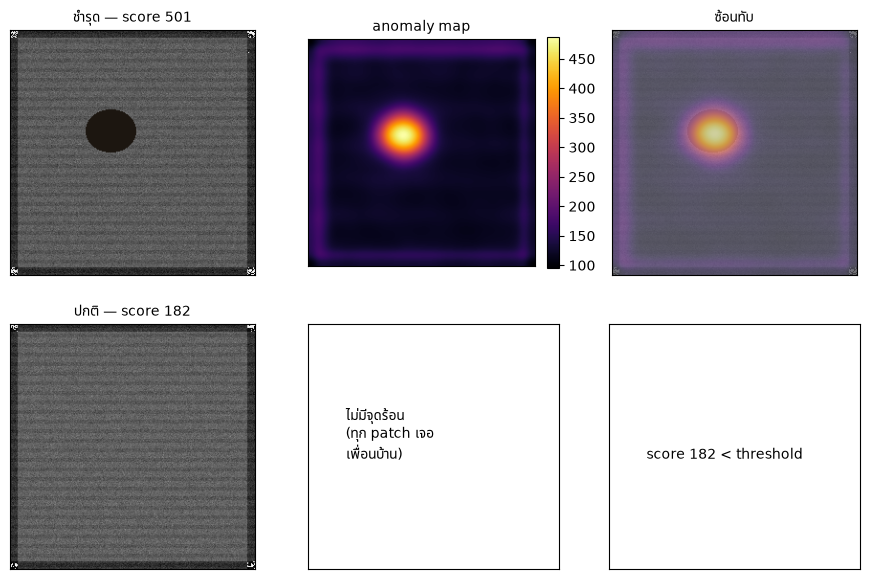

In [13]:
i_top = int(np.argmax(s_def))          # ภาพชำรุดที่ได้คะแนนสูงสุด
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for row, (path, score, m) in enumerate([
    (defect_paths[i_top], s_def[i_top], maps_def[i_top]),
    (good_paths[0], s_good[0], None),
]):
    img = Image.open(path).convert("RGB")
    axes[row, 0].imshow(img)
    tag = "ชำรุด" if row == 0 else "ปกติ"
    axes[row, 0].set_title(f"{tag} — score {score:.0f}", fontsize=10)
    if m is not None:
        im = axes[row, 1].imshow(m, cmap="inferno")
        axes[row, 1].set_title("anomaly map", fontsize=10)
        fig.colorbar(im, ax=axes[row, 1], fraction=0.046)
        axes[row, 2].imshow(img, alpha=0.45)
        axes[row, 2].imshow(m, cmap="inferno", alpha=0.55)
        axes[row, 2].set_title("ซ้อนทับ", fontsize=10)
    else:
        axes[row, 1].text(
            0.15, 0.45, "ไม่มีจุดร้อน\n(ทุก patch เจอ\nเพื่อนบ้าน)",
            fontsize=10,
        )
        axes[row, 2].text(0.15, 0.45, f"score {score:.0f} < threshold",
                          fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

**อ่าน heatmap:** จุดสว่างของภาพชำรุดควรตรงตำแหน่ง defect ที่เราวาดไว้ — นี่คือข้อดีใหญ่ของ PatchCore เหนือ "โมเดลให้ตัวเลขอย่างเดียว": ผู้ตรวจเห็น**ว่าชำรุดตรงไหน** และใช้กลับไปเช็คชิ้นงานจริงได้ (นักเมโทรโลยีคุ้นเคยดีกับแนวคิด "วัดได้ + บอกตำแหน่งที่ผิดปกติ")

## 7. ทดสอบกับภาพใหม่ — และภาพของคุณเอง

`score_paths()` รับ path อะไรก็ได้ — ลองกับภาพที่โมเดล**ไม่เคยเห็นเลย** (seed ใหม่):

In [14]:
unseen_normal = metal_plate(7777)            # แผ่นปกติที่ไม่เคยเห็น
unseen_defect = add_defect(metal_plate(8888), kind=1, i=5)
p_unseen = SAMPLE_DIR.parent / "m6_unseen"
p_unseen.mkdir(exist_ok=True)
unseen_normal.save(p_unseen / "unseen_normal.png")
unseen_defect.save(p_unseen / "unseen_defect.png")

s_unseen, _ = score_paths(
    [str(p_unseen / "unseen_normal.png"), str(p_unseen / "unseen_defect.png")]
)
for name, s in zip(["ปกติใหม่", "ชำรุดใหม่"], s_unseen):
    verdict = "ชำรุด!" if s > THRESHOLD else "ปกติ"
    print(f"{name}: score = {s:.0f} → โมเดลตอบ {verdict}")

ปกติใหม่: score = 137 → โมเดลตอบ ปกติ
ชำรุดใหม่: score = 216 → โมเดลตอบ ชำรุด!


**โมเดลตอบถูกทั้งสองใบ** — โดยไม่เคยเห็นภาพนี้มาก่อน และไม่เคยเห็น label "ชำรุด" ใด ๆ ตอนเทรน

### จะใช้รูปของผู้เรียนเองยังไง?

โครงสร้างเดียวกันทั้งหมด — เพียงเปลี่ยนโฟลเดอร์ภาพ:

1. ถ่ายภาพ "ปกติ" 15–20 ใบ วางใน `data/my_sample/good/` และภาพชำรุด 3–5 ใบใน `data/my_sample/defect/`
2. เปลี่ยน `root=str(SAMPLE_DIR)` เป็นโฟลเดอร์ของคุณ แล้วรัน `engine.fit` ใหม่ (จบในหลักวินาที)
3. ใช้ `score_paths()` กับภาพไหนก็ได้ — แม้แต่ภาพที่ถ่ายใหม่หลังเทรน

**กฎการถ่ายรูปสำคัญ** (รายละเอียดเต็มใน exercise ข้อ 1): มุมกล้อง ระยะ และแสงต้อง**คงที่**ระหว่างภาพทุกใบ — PatchCore เรียนรู้ "หน้าตาปกติ" จากสิ่งที่อยู่ในเฟรมทั้งหมด ถ้ามุม/แสงเปลี่ยน โมเดลจะถือว่า**การเปลี่ยนนั้นเองเป็น anomaly**

## 8. ข้อจำกัดที่ต้องรู้ก่อนใช้จริง

| สถานการณ์ | เกิดอะไร | ทางแก้ |
|---|---|---|
| วางชิ้นงานไม่ตรงตำแหน่งเดิม | patch ทั้งภาพ "หาเพื่อนไม่เจอ" — false positive เยอะ | fix ตำแหน่ง/ใช้ jig, หรือเพิ่มความหลากหลายของภาพปกติ (จัดวางหลายแบบ) |
| แสง/กล้องเปลี่ยน | ทั้งภาพดู "แปลก" — false positive | คุมแสง, เทรนซ้ำด้วยภาพใหม่ |
| ความชำรุดจิ๋วเล็กกว่า 1 patch | feature กลาง ๆ มองไม่เห็น — FN | ถ่ายใกล้ขึ้น (แต่ต้องคงมุมเดิม) |
| "ปกติ" ที่ให้เทรนมี defect แฝง | โมเดลจะคิดว่า defect นั้น "ปกติ" | คัดภาพเทรนด้วยตาก่อน — garbage in, garbage out |

**สรุปโมดูล:**

- สร้างโมเดลตรวจความผิดปกติจากภาพปกติ 20 ใบ **ไม่ใช้ label ชำรุดเลย** — เทรนจบในไม่กี่วินาทีบน CPU
- PatchCore = backbone feature → memory bank (coreset) → kNN distance = คะแนน + heatmap
- threshold คือการตัดสินใจเชิงธุรกิจ/เมโทรโลยี (FP vs FN) — ไม่ใช่สิ่งที่โมเดลบอกเรา
- จุดแข็ง: ข้อมูลน้อย, ไม่ต้อง label, บอกตำแหน่ง defect ได้ / จุดอ่อน: ไวต่อการจัดวางและแสง

**ต่อไป (M7):** เราจะใช้ Grad-CAM มองเข้าไปในโมเดล classification ของ M1 — จะเห็นว่า PatchCore ที่นี่ก็คือ "explainability ในตัว" แบบหนึ่ง เพราะ heatmap มาจากกลไกของ algorithm โดยตรง

**เชิงลึกของ algorithm ทั้งหมด** (ทำไม layer2/3, coreset greedy ทำงานยังไง, Johnson–Lindenstrauss, threshold แบบ adaptive ของ anomalib): อ่านต่อใน `explanation.md`